# Open recordings and verify quality and coverage

In [1]:
import sys
import os
import time
import datetime as dt
import math
import numpy as np 
import scipy as sp
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json 
import heartpy as hp

from scipy.signal import butter, filtfilt, argrelextrema
from scipy import interpolate
from scipy.interpolate import interp1d

In [2]:
%load_ext autoreload
%autoreload 1
%aimport qex
%aimport rp2
%aimport mh

In [3]:
 %reload_ext autoreload

In [4]:
def rmssd(ibi_list):
    ibi_list = pd.Series(ibi_list)
    ms = np.sqrt(ibi_list.diff().pow(2).sum()/(len(ibi_list)-1))
    return ms

def HR_avg(ibi_list):
    ibi_list = pd.Series(ibi_list)
    bpm = 60000/ibi_list.mean()
    return bpm


def get_spectrogram(datain,F,W,J,scale='log'):
    '''Makes a spectrogram of the given data.
    #
    df: dataframe with data
    F: sampling frequency
    W: Window size
    J: Separation between windows
    #
    output: if input is Series output is a signle DF with spectrogram
            if intput is DF the output is dictionary with one spectrogram per column of the input dataframe
    '''
    K = range(0,len(datain)-W,J) # starting point for the windows
    K0 = [int(x+W/2) for x in K] # placing them in the middle point timestamp
    new_index = [datain.index[x] for x in K0] # extracting those timestamps
    col_freqs = [x*F/W for x in range(int(W/2)+1) ] # values of resolved freqs
    #   print(len(new_index),len(col_freqs))
    han = np.hanning(W)
    #dic = {'window_size':W,'sampling_frequency':F}
    #
    dic = {}
    for col in datain.columns:
        fourier = np.zeros((len(new_index),len(col_freqs)))
        temp = np.zeros((1,int(W/2)+1))
        j = 0
        D = datain[col]
#         D = D.diff() # discrete derivative
        D = D.dropna() # discarding nans and concatenating
        if len(D)==0:
            continue
        #   
        K0 = range(0,len(D)-W,J) # starting point for the windows
        for T0 in K0:
            data0 = D.iloc[T0:T0+W]*han
            if scale=='log':
                temp = 10*np.log10(2*abs(np.fft.fft(data0,axis=0)))
            elif scale=='abs':
                temp = abs(np.fft.fft(data0,axis=0))
            fourier[j,:] = temp[:int(W/2)+1]
            j = 1 + j
            #
        res = pd.DataFrame(fourier,index=new_index,columns=col_freqs)
#         res1 = res / (res.columns) # multiplicative adjustment for discrete derivative
        dic[col] = res#1      
        #print('Ready with ',col)
    output = dic
    #
    return output


## load example data

In [5]:
mydpi = 196
sess_tag = '240402'

In [6]:
Timing_file = pd.read_csv('../Timing/sessions2_times.csv')
Timing_file['DateTime']=Timing_file['Times']+', '+Timing_file['Date']
Timing_file['Date']=pd.to_datetime(Timing_file['Date'])
Timing_file['DateTime']=pd.to_datetime(Timing_file['DateTime'])
Timing_file
sess_times = Timing_file.query('Session==3')
Excerpt_times = sess_times.loc[:,'DateTime']
sess_times

,Times,Date,Session,DateTime
35,12:12:35,2024-04-02,3,2024-04-02 12:12:35
36,12:15:32,2024-04-02,3,2024-04-02 12:15:32
37,12:19:17,2024-04-02,3,2024-04-02 12:19:17
38,12:21:22,2024-04-02,3,2024-04-02 12:21:22
39,12:24:35,2024-04-02,3,2024-04-02 12:24:35
40,12:27:54,2024-04-02,3,2024-04-02 12:27:54
41,12:30:21,2024-04-02,3,2024-04-02 12:30:21
42,12:33:05,2024-04-02,3,2024-04-02 12:33:05
43,12:37:32,2024-04-02,3,2024-04-02 12:37:32
44,12:41:52,2024-04-02,3,2024-04-02 12:41:52


In [7]:
data_loc = '../Equivitals_Sessions2/'
eqfiles = qex.qiosk_rec_check(data_loc,'','/')
eqfiles = qex.remove_tz_from_dataframe(eqfiles)

In [8]:
eqfiles

,Signal,DevName,ID,Date,Session,FileName,FileType,FileSize,RecStart,RecEnd,...,SubjectNames,SENSOR ID,SUBJECT ID,SUBJECT AGE,HR(BPM),HRC(%),BELT OFF,LEAD OFF,MOTION,BODY POSITION
0,DATA,BLUETOOTH02,5022285,231005,101,DATA-BLUETOOTH02-5022285-23100500_0.CSV,csv,24903,2023-10-05 12:00:40,2023-10-05 13:08:10,...,[BLUETOOTH02],5022285.0,BLUETOOTH02,53.0,83,97.0,0.0,0.0,Stationary,Upright
1,DATA,BLUETOOTH01,5022281,231005,101,DATA-BLUETOOTH01-5022281-23100500_0.CSV,csv,23560,2023-10-05 12:02:19,2023-10-05 13:06:19,...,[BLUETOOTH01],5022281.0,BLUETOOTH01,53.0,83,97.0,0.0,0.0,Stationary,Upright
2,DATA,VA308,5022131,231012,101,DATA-VA308-5022131-23101200_0.CSV,csv,21514,2023-10-12 11:03:36,2023-10-12 12:06:06,...,[VA308],5022131.0,VA308,53.0,88,98.0,0.0,0.0,Stationary,Upright
3,DATA,VA307,5022127,231012,101,DATA-VA307-5022127-23101200_0.CSV,csv,21264,2023-10-12 11:05:21,2023-10-12 12:07:06,...,[VA307],5022127.0,VA307,53.0,85,97.0,0.0,0.0,Stationary,Upright
4,DATA,BLUETOOTH02,5022285,240402,0,DATA-BLUETOOTH02-5022285-24040200.CSV,csv,27639,2024-04-02 11:54:11,2024-04-02 13:09:11,...,[BLUETOOTH02],5022285.0,BLUETOOTH02,53.0,79,98.0,0.0,0.0,Stationary,Upright
5,DATA,BLUETOOTH01,5022281,240402,0,DATA-BLUETOOTH01-5022281-24040200.CSV,csv,27556,2024-04-02 11:54:41,2024-04-02 13:09:41,...,[BLUETOOTH01],5022281.0,BLUETOOTH01,53.0,83,97.0,0.0,0.0,Stationary,Upright
6,DATA,BLUETOOTH02,5022285,240410,0,DATA-BLUETOOTH02-5022285-24041000.CSV,csv,27261,2024-04-10 10:48:28,2024-04-10 12:02:28,...,[BLUETOOTH02],5022285.0,BLUETOOTH02,53.0,81,98.0,0.0,0.0,Stationary,Upright
7,DATA,BLUETOOTH01,5022281,240410,0,DATA-BLUETOOTH01-5022281-24041000.CSV,csv,27337,2024-04-10 10:49:06,2024-04-10 12:03:21,...,[BLUETOOTH01],5022281.0,BLUETOOTH01,53.0,89,97.0,0.0,0.0,Stationary,Upright
8,DATA,BLUETOOTH02,5022285,240417,101,DATA-BLUETOOTH02-5022285-24041700_0.CSV,csv,29048,2024-04-17 10:14:41,2024-04-17 11:33:57,...,[BLUETOOTH02],5022285.0,BLUETOOTH02,53.0,79,98.0,0.0,0.0,Stationary,Upright
9,DATA,BLUETOOTH01,5022281,240417,101,DATA-BLUETOOTH01-5022281-24041700_0.CSV,csv,29785,2024-04-17 10:15:01,2024-04-17 11:36:16,...,[BLUETOOTH01],5022281.0,BLUETOOTH01,53.0,90,97.0,0.0,0.0,Stationary,Upright


It seems we don't have the correct physiologial measurement files, dating 23 oct and 24 april, not May (24) and June 2023 (7, 14, 21, 28).


Below I've constructed the evaluation process, which should be easily ammended to evaluate the correct files.

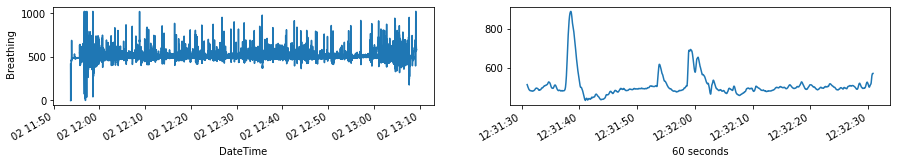

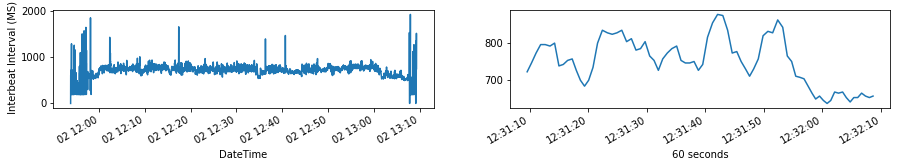

In [69]:
sig_tags = ['RESPloc', 'RRloc'] # 'ACCloc', 'DATAloc', , 'ECGloc'
recindex = 4
for sig_file in sig_tags:
    V=pd.read_csv(eqfiles.loc[recindex,sig_file])
    qex.test_plot_signals(V)

In [66]:
# Session 4,5, 2024-04-02 11:54:11+00:00, aligned at 12:10? 
#timing_adjustment = eqfiles.loc[recindex,'RecStart'] - Timing_file.loc[0,'Times'] + pd.to_timedelta(600,unit='s')
# timing_adjustment = - pd.to_timedelta(3600,unit='s')

In [70]:
Excerpt_times

35   2024-04-02 12:12:35
36   2024-04-02 12:15:32
37   2024-04-02 12:19:17
38   2024-04-02 12:21:22
39   2024-04-02 12:24:35
40   2024-04-02 12:27:54
41   2024-04-02 12:30:21
42   2024-04-02 12:33:05
43   2024-04-02 12:37:32
44   2024-04-02 12:41:52
45   2024-04-02 12:44:48
46   2024-04-02 12:49:17
47   2024-04-02 12:52:07
48   2024-04-02 12:54:15
49   2024-04-02 12:57:59
Name: DateTime, dtype: datetime64[ns]

[Timestamp('2024-04-02 12:12:35'), Timestamp('2024-04-02 12:13:35')]
2024-04-02 11:53:43.039000+00:00


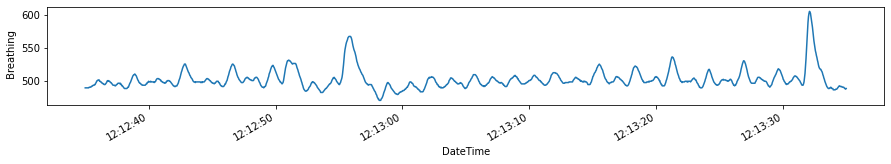

2024-04-02 11:53:47.687000+00:00


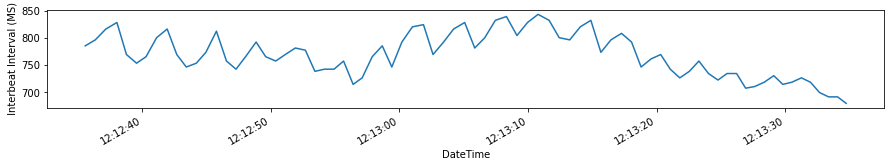

In [72]:
sig_tags = ['RESPloc', 'RRloc'] # 'ACCloc', 'DATAloc', , 'ECGloc'
# recindex = 4

t1 = Excerpt_times.iloc[0]# + timing_adjustment 
t2 =  Excerpt_times.iloc[0]+ pd.to_timedelta(60,unit='s') #+ timing_adjustment 
print([t1,t2])
for sig_file in sig_tags:
    V=pd.read_csv(eqfiles.loc[recindex,sig_file])
    V['DateTime'] = pd.to_datetime(V['DateTime'])
    print(V.loc[0,'DateTime'])
    V = qex.remove_tz_from_dataframe(V)
    qex.test_plot_signals_interval(V,t1,t2)

### cardiac cleaning

In [9]:
Evs = []

In [41]:
sess_times = Timing_file.query('Session==1')
Excerpt_times = sess_times.loc[:,'DateTime']
sess_times

,Times,Date,Session,DateTime
0,12:11:08,2023-10-05,1,2023-10-05 12:11:08
1,12:14:06,2023-10-05,1,2023-10-05 12:14:06
2,12:17:55,2023-10-05,1,2023-10-05 12:17:55
3,12:21:13,2023-10-05,1,2023-10-05 12:21:13
4,12:24:31,2023-10-05,1,2023-10-05 12:24:31
5,12:27:10,2023-10-05,1,2023-10-05 12:27:10
6,12:31:00,2023-10-05,1,2023-10-05 12:31:00
7,12:33:48,2023-10-05,1,2023-10-05 12:33:48
8,12:36:20,2023-10-05,1,2023-10-05 12:36:20
9,12:39:48,2023-10-05,1,2023-10-05 12:39:48


In [42]:
sess_tag = 'Sess231005'

In [43]:
recindex = 0 
eqfiles.loc[recindex,['DevName','Date','RecStart','RecEnd']]

DevName             BLUETOOTH02
Date                     231005
RecStart    2023-10-05 12:00:40
RecEnd      2023-10-05 13:08:10
Name: 0, dtype: object

In [45]:
recindex = 1
eqfiles.loc[recindex,['DevName','Date','RecStart','RecEnd']]

DevName             BLUETOOTH01
Date                     231005
RecStart    2023-10-05 12:02:19
RecEnd      2023-10-05 13:06:19
Name: 1, dtype: object

In [46]:
dev_tag = eqfiles.loc[recindex,'DevName']

V = pd.read_csv(eqfiles.loc[recindex,'RRloc']) 
V['DateTime'] = pd.to_datetime(V['DateTime'])
V = qex.remove_tz_from_dataframe(V)
V['c_sTime'] = (V['DateTime']-eqfiles.loc[recindex,'RecStart']).dt.total_seconds()
sig_t = V['c_sTime']
sig_v = V[' Interbeat Interval (MS)']

C = pd.read_csv(eqfiles.loc[recindex,'ECGloc'])
C['DateTime'] = pd.to_datetime(C['DateTime'])
C = qex.remove_tz_from_dataframe(C)
C['c_sTime'] = (C['DateTime']-eqfiles.loc[recindex,'RecStart']).dt.total_seconds()
R = pd.read_csv(eqfiles.loc[recindex,'RESPloc'])
R['DateTime'] = pd.to_datetime(R['DateTime'])
R = qex.remove_tz_from_dataframe(R)
R['c_sTime'] = (R['DateTime']-eqfiles.loc[recindex,'RecStart']).dt.total_seconds()

atype='default'
IBI=mh.clean_IBI(sig_t,sig_v,activitytype=atype)
newIBI = mh.contact_noise_cut(C['c_sTime'],C[' Lead 1'],V['c_sTime'],V[' Interbeat Interval (MS)'],0.25)
newV = V.loc[newIBI.index,:]
newIBI = mh.contact_noise_cut(C['c_sTime'],C[' Lead 2'],newV['c_sTime'],newV[' Interbeat Interval (MS)'],0.25)
newV = newV.loc[newIBI.index,:]
newIBI=mh.clean_IBI(newV['c_sTime'],newV[' Interbeat Interval (MS)'],activitytype=atype)

Respwave = R.query('c_sTime>200').copy()
Respwave.set_index('c_sTime',drop=True,inplace=True)
Breaths = rp2.breath_cycles(rp2.EQ_Inspiration_Extract(Respwave.loc[:,' Breathing']),Respwave.loc[:,' Breathing'])

A = pd.read_csv(eqfiles.loc[recindex,'ACCloc'])
A['DateTime'] = pd.to_datetime(A['DateTime'])
A = qex.remove_tz_from_dataframe(A)
A['c_sTime'] = (A['DateTime']-eqfiles.loc[recindex,'RecStart']).dt.total_seconds()
A['QoM'] = np.sqrt(np.square(A.loc[:,[' Vert Accelerometer', ' Lat Accelerometer',' Long Accelerometer']].diff()).sum(axis=1))
acc_cols = [' Vert Accelerometer', ' Lat Accelerometer',' Long Accelerometer','QoM']
sf = 256
spec= get_spectrogram(A[acc_cols],sf,2048,256,scale='log')
Hz=np.array(spec['QoM'].loc[:,:6].columns)
BPM = np.round(Hz*60,2)


D = pd.read_csv(eqfiles.loc[recindex,'DATAloc'])
D['DateTime'] = pd.to_datetime(D['DateTime'])
D = qex.remove_tz_from_dataframe(D)
D['c_sTime'] = (D['DateTime']-eqfiles.loc[recindex,'RecStart']).dt.total_seconds()

D['HR(BPM)']

Exticks = (Excerpt_times-eqfiles.loc[recindex,'RecStart']).dt.total_seconds()
xrange = [A['c_sTime'].min(),A['c_sTime'].max()]

tstart = Excerpt_times.iloc[0].round('min')-pd.to_timedelta(60,'s')
samples = int(np.floor((Excerpt_times.iloc[-1]-tstart).total_seconds()/60))+1
print(samples)

t_int =60
sig_ex = sess_tag + ' '+ dev_tag
session_stats = {}
for i in range(samples): #17
    t = tstart+i*pd.to_timedelta(60,'s')
    # needs to be corrected when the files have the right correspondence    
    cht = (t-eqfiles.loc[recindex,'RecStart']).total_seconds()
    chx = cht+t_int
    
    interval_stats = {}
    interval_stats['Device'] = dev_tag
    interval_stats['Start Time'] = t.strftime('%Y/%m/%d %H:%M:%S')
    interval_stats['Recording'] = recindex
    
    Ex = C.query('c_sTime>@cht and c_sTime<@chx').copy()
    Ex = V.query('c_sTime>@cht and c_sTime<@chx').copy()
    interval_stats['Initial Beat Count'] = len(Ex)

    Ex = newIBI.query('time>@cht and time<@chx').copy()
    interval_stats['Cleaned Beat Count'] =Ex['IBI'].notna().sum()
    interval_stats['PC Removed'] = 100*np.round((interval_stats['Initial Beat Count'] - interval_stats['Cleaned Beat Count'])/interval_stats['Initial Beat Count'],3)
    interval_stats['Avg HR'] = HR_avg(Ex['IBI'])
    interval_stats['RMSSD'] =rmssd(Ex['IBI'])
    Ex = D.query('c_sTime>@cht and c_sTime<@chx').copy()
    interval_stats['Avg eqHR'] = Ex['HR(BPM)'].mean()
    interval_stats['Mode Motion'] = Ex['MOTION'].mode()[0]
    interval_stats['Mode Posture'] = Ex['BODY POSITION'].mode()[0]

    Ex = R.query('c_sTime>@cht and c_sTime<@chx').copy()
    Ex = Breaths.query('In>@cht and Ex<@chx').copy()
    interval_stats['Breath Count'] = len(Ex)
    interval_stats['Avg BR'] =(60/Ex['Period_T']).mean()
    interval_stats['Avg IE ratio'] =(Ex['IE_Ratio']).mean()
    interval_stats['Seq Var'] =np.power(10,np.log10((Ex['Period_T']/Ex['Period_T'].shift(-1))).abs().mean())


    Ex = A.query('c_sTime>@cht and c_sTime<@chx').copy()
    interval_stats['Avg QoM'] =Ex['QoM'].mean()
    print(interval_stats)
    session_stats[t.strftime('%Y/%m/%d %H:%M:%S')] = interval_stats
Evaluated_Intervals =pd.DataFrame(data=session_stats).transpose()
Evaluated_Intervals.to_csv('_'.join(['./MinuteFiles/'+sess_tag,dev_tag,'minutestats.csv']))

Clipped!
50
{'Device': 'BLUETOOTH01', 'Start Time': '2023/10/05 12:10:00', 'Recording': 1, 'Initial Beat Count': 79, 'Cleaned Beat Count': 79, 'PC Removed': 0.0, 'Avg HR': 79.53420474184942, 'RMSSD': 33.20603899354793, 'Avg eqHR': 77.75, 'Mode Motion': 'Stationary', 'Mode Posture': 'Upright', 'Breath Count': 20, 'Avg BR': 20.773383874153318, 'Avg IE ratio': 0.39994090098474616, 'Seq Var': 1.117991275065597, 'Avg QoM': 11.08829640900268}
{'Device': 'BLUETOOTH01', 'Start Time': '2023/10/05 12:11:00', 'Recording': 1, 'Initial Beat Count': 77, 'Cleaned Beat Count': 77, 'PC Removed': 0.0, 'Avg HR': 77.1504433645609, 'RMSSD': 39.09452108604693, 'Avg eqHR': 78.0, 'Mode Motion': 'Stationary', 'Mode Posture': 'Upright', 'Breath Count': 15, 'Avg BR': 17.65083563901583, 'Avg IE ratio': 0.33426134125696677, 'Seq Var': 1.3052683077940324, 'Avg QoM': 11.1446089831331}
{'Device': 'BLUETOOTH01', 'Start Time': '2023/10/05 12:12:00', 'Recording': 1, 'Initial Beat Count': 80, 'Cleaned Beat Count': 80, 'P

In [111]:
sess_tag = 'Sess240417'
dev_tag = eqfiles.loc[recindex,'DevName']

V = pd.read_csv(eqfiles.loc[recindex,'RRloc']) 
V['DateTime'] = pd.to_datetime(V['DateTime'])
V = qex.remove_tz_from_dataframe(V)
V['c_sTime'] = (V['DateTime']-eqfiles.loc[recindex,'RecStart']).dt.total_seconds()
sig_t = V['c_sTime']
sig_v = V[' Interbeat Interval (MS)']

C = pd.read_csv(eqfiles.loc[recindex,'ECGloc'])
C['DateTime'] = pd.to_datetime(C['DateTime'])
C = qex.remove_tz_from_dataframe(C)
C['c_sTime'] = (C['DateTime']-eqfiles.loc[recindex,'RecStart']).dt.total_seconds()
R = pd.read_csv(eqfiles.loc[recindex,'RESPloc'])
R['DateTime'] = pd.to_datetime(R['DateTime'])
R = qex.remove_tz_from_dataframe(R)
R['c_sTime'] = (R['DateTime']-eqfiles.loc[recindex,'RecStart']).dt.total_seconds()

atype='default'
IBI=mh.clean_IBI(sig_t,sig_v,activitytype=atype)
newIBI = mh.contact_noise_cut(C['c_sTime'],C[' Lead 1'],V['c_sTime'],V[' Interbeat Interval (MS)'],0.25)
newV = V.loc[newIBI.index,:]
newIBI = mh.contact_noise_cut(C['c_sTime'],C[' Lead 2'],newV['c_sTime'],newV[' Interbeat Interval (MS)'],0.25)
newV = newV.loc[newIBI.index,:]
newIBI=mh.clean_IBI(newV['c_sTime'],newV[' Interbeat Interval (MS)'],activitytype=atype)

Respwave = R.query('c_sTime>200').copy()
Respwave.set_index('c_sTime',drop=True,inplace=True)
Breaths = rp2.breath_cycles(rp2.EQ_Inspiration_Extract(Respwave.loc[:,' Breathing']),Respwave.loc[:,' Breathing'])

A = pd.read_csv(eqfiles.loc[recindex,'ACCloc'])
A['DateTime'] = pd.to_datetime(A['DateTime'])
A = qex.remove_tz_from_dataframe(A)
A['c_sTime'] = (A['DateTime']-eqfiles.loc[recindex,'RecStart']).dt.total_seconds()
A['QoM'] = np.sqrt(np.square(A.loc[:,[' Vert Accelerometer', ' Lat Accelerometer',' Long Accelerometer']].diff()).sum(axis=1))
acc_cols = [' Vert Accelerometer', ' Lat Accelerometer',' Long Accelerometer','QoM']
sf = 256
spec= get_spectrogram(A[acc_cols],sf,2048,256,scale='log')
Hz=np.array(spec['QoM'].loc[:,:6].columns)
BPM = np.round(Hz*60,2)


D = pd.read_csv(eqfiles.loc[recindex,'DATAloc'])
D['DateTime'] = pd.to_datetime(D['DateTime'])
D = qex.remove_tz_from_dataframe(D)
D['c_sTime'] = (D['DateTime']-eqfiles.loc[recindex,'RecStart']).dt.total_seconds()

D['HR(BPM)']

Exticks = (Excerpt_times-eqfiles.loc[recindex,'RecStart']).dt.total_seconds()
xrange = [A['c_sTime'].min(),A['c_sTime'].max()]



Clipped!


/Users/finn/.pyenv/versions/3.9.0/lib/python3.9/site-packages/seaborn/utils.py:61: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.draw()
/Users/finn/.pyenv/versions/3.9.0/lib/python3.9/site-packages/seaborn/utils.py:61: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.draw()
/Users/finn/.pyenv/versions/3.9.0/lib/python3.9/site-packages/seaborn/utils.py:61: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.draw()
<ipython-input-112-c28ea7d92584>:32: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.savefig('_'.join(['./plots/'+sess_tag + '/'+sess_tag,'FullRec',dev_tag+'.jpg']))
/Users/finn/.pyenv/versions/3.9.0/lib/python3.9/site-packages/IPython/core/pylabtools.py:132: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


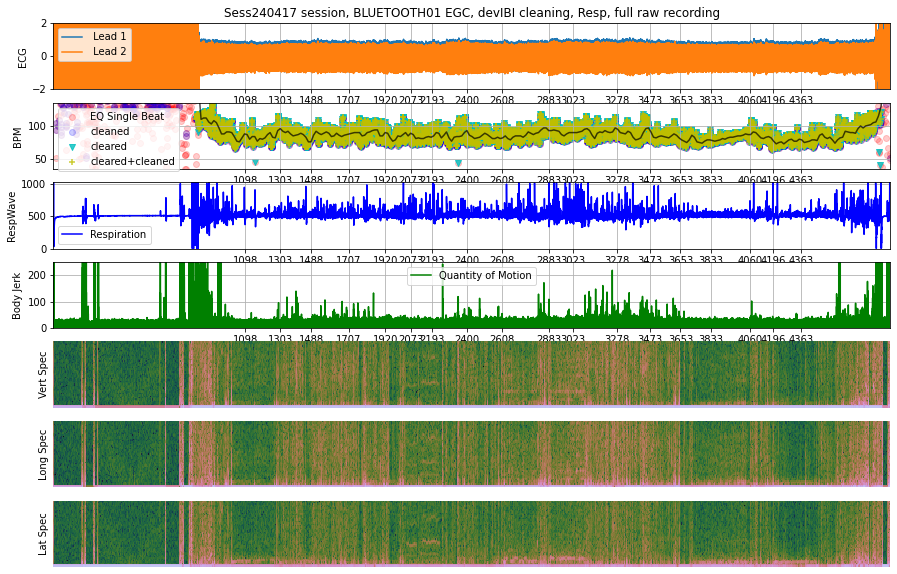

In [112]:
fig, (ax) = plt.subplots(7, 1,figsize = [15,10])
ax[0].plot(C['c_sTime'],C[[' Lead 1',' Lead 2']],label=[' Lead 1',' Lead 2'])
ax[0].set_title(sess_tag + ' session, '+ dev_tag +' EGC, devIBI cleaning, Resp, full raw recording' )
ax[0].set(ylabel = 'ECG',xticks = Exticks,xlim = xrange,ylim = [-2,2])
ax[0].grid()
ax[0].legend()

ax[1].scatter(x =sig_t,y=(60000/sig_v),color='r',alpha = 0.2,label='EQ Single Beat')
ax[1].scatter(x = IBI.index,y = (60000/IBI['IBI']),color='b',alpha = 0.2,label='cleaned')
ax[1].scatter(x =newV['c_sTime'],y=(60000/newV[' Interbeat Interval (MS)']),color='c',marker = 'v',alpha = 0.8,label='cleared')
ax[1].scatter(x = newIBI.index,y = (60000/newIBI['IBI']),color='y',marker = '+',alpha = 0.8,label='cleared+cleaned')
ax[1].grid()
ax[1].legend()
ax[1].plot(D['c_sTime'],D['HR(BPM)'],alpha=0.7,c='k',label='EQHR')
ax[1].set(ylabel='BPM',ylim=[35,135],xticks = Exticks, xlim = xrange)

ax[2].plot(R['c_sTime'],R[' Breathing'],color = 'b',label='Respiration')
ax[2].set(xlabel = 'Time (s), Session',ylabel = 'RespWave',xticks = Exticks,xlim = xrange,ylim = [0,1024])
ax[2].grid()
ax[2].legend()

ax[3].plot(A['c_sTime'],A['QoM'],color = 'g',label='Quantity of Motion')
ax[3].set(xticks = Exticks,ylabel = 'Body Jerk',ylim = [0,250], xlim = xrange)
ax[3].grid()
ax[3].legend()
chart = sns.heatmap(data=spec[' Vert Accelerometer'].loc[:,Hz[::-1]].transpose(),vmin=0, vmax=80,cmap="cubehelix", cbar = False, ax=ax[4])
ax[4].set(xticks = [],yticks=[],ylabel='Vert Spec')
chart = sns.heatmap(data=spec[' Long Accelerometer'].loc[:,Hz[::-1]].transpose(),vmin=0, vmax=80,cmap="cubehelix", cbar = False, ax=ax[5])
ax[5].set(xticks = [],yticks=[],ylabel='Long Spec')
chart = sns.heatmap(data=spec[' Lat Accelerometer'].loc[:,Hz[::-1]].transpose(),vmin=0, vmax=80,cmap="cubehelix",cbar = False,  ax=ax[6])
ax[6].set(xticks = [],yticks=[],ylabel='Lat Spec')
plt.savefig('_'.join(['./plots/'+sess_tag + '/'+sess_tag,'FullRec',dev_tag+'.jpg']))
plt.show()

{'Device': 'BLUETOOTH01', 'Start Time': '2024/04/17 10:33:19', 'Recording': 9, 'Initial Beat Count': 81, 'Cleaned Beat Count': 79, 'PC Removed': 2.5, 'Avg HR': 81.57505249027639, 'RMSSD': 30.194370336206717, 'Avg eqHR': 83.75, 'Mode Motion': 'Stationary', 'Mode Posture': 'Upright', 'Breath Count': 15, 'Avg BR': 15.421802290072744, 'Avg IE ratio': 0.3891257188732195, 'Seq Var': 1.3641906735770484, 'Avg QoM': 11.185698172923084}


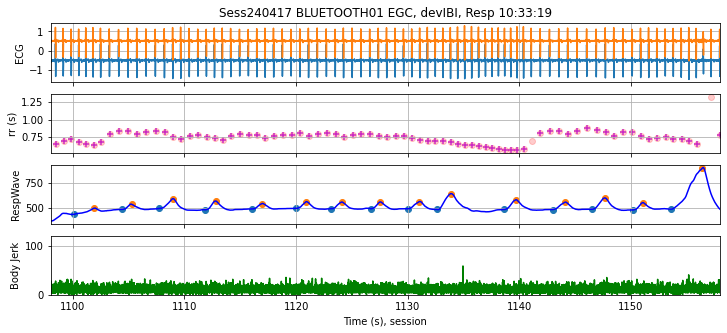

{'Device': 'BLUETOOTH01', 'Start Time': '2024/04/17 10:36:44', 'Recording': 9, 'Initial Beat Count': 89, 'Cleaned Beat Count': 88, 'PC Removed': 1.0999999999999999, 'Avg HR': 89.13047147993721, 'RMSSD': 25.20889994354447, 'Avg eqHR': 92.5, 'Mode Motion': 'Stationary', 'Mode Posture': 'Upright', 'Breath Count': 19, 'Avg BR': 23.009336208226802, 'Avg IE ratio': 0.4335102702939782, 'Seq Var': 1.5243933802036245, 'Avg QoM': 12.668414495360986}


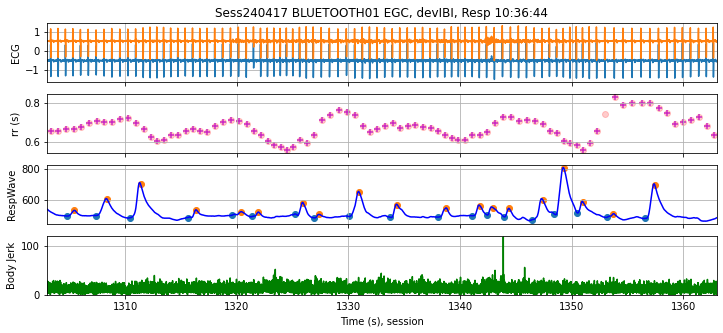

{'Device': 'BLUETOOTH01', 'Start Time': '2024/04/17 10:39:49', 'Recording': 9, 'Initial Beat Count': 90, 'Cleaned Beat Count': 89, 'PC Removed': 1.0999999999999999, 'Avg HR': 89.59280573125514, 'RMSSD': 22.41012010556988, 'Avg eqHR': 88.5, 'Mode Motion': 'Stationary', 'Mode Posture': 'Upright', 'Breath Count': 14, 'Avg BR': 18.83236698214697, 'Avg IE ratio': 0.3629869180107029, 'Seq Var': 1.9241236586816104, 'Avg QoM': 13.114947150270927}


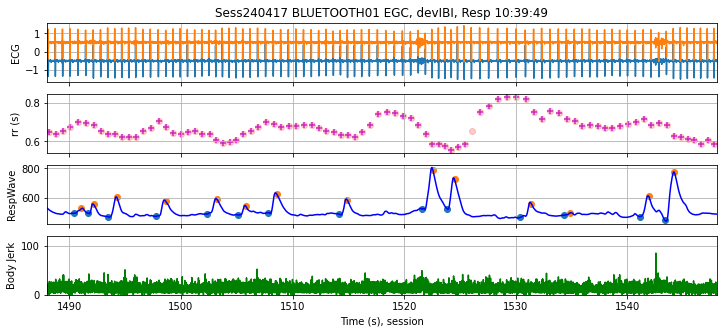

{'Device': 'BLUETOOTH01', 'Start Time': '2024/04/17 10:43:28', 'Recording': 9, 'Initial Beat Count': 90, 'Cleaned Beat Count': 90, 'PC Removed': 0.0, 'Avg HR': 90.24667424293068, 'RMSSD': 27.154985885228633, 'Avg eqHR': 89.25, 'Mode Motion': 'Stationary', 'Mode Posture': 'Upright', 'Breath Count': 17, 'Avg BR': 21.32934675561874, 'Avg IE ratio': 0.5210401742325382, 'Seq Var': 1.9165141057475101, 'Avg QoM': 13.027689281752883}


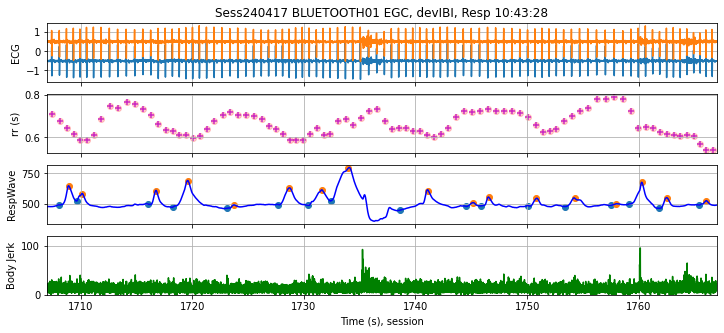

{'Device': 'BLUETOOTH01', 'Start Time': '2024/04/17 10:47:01', 'Recording': 9, 'Initial Beat Count': 81, 'Cleaned Beat Count': 81, 'PC Removed': 0.0, 'Avg HR': 80.63579499261668, 'RMSSD': 30.951777008759933, 'Avg eqHR': 82.66666666666667, 'Mode Motion': 'Stationary', 'Mode Posture': 'Upright', 'Breath Count': 24, 'Avg BR': 25.701095152692904, 'Avg IE ratio': 0.5448542121983387, 'Seq Var': 1.254626440336327, 'Avg QoM': 12.866091097999261}


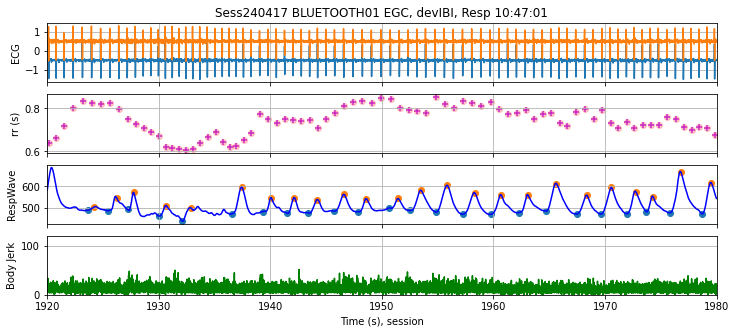

{'Device': 'BLUETOOTH01', 'Start Time': '2024/04/17 10:49:34', 'Recording': 9, 'Initial Beat Count': 81, 'Cleaned Beat Count': 81, 'PC Removed': 0.0, 'Avg HR': 81.14606291324384, 'RMSSD': 40.5124980715828, 'Avg eqHR': 82.75, 'Mode Motion': 'Stationary', 'Mode Posture': 'Upright', 'Breath Count': 18, 'Avg BR': 23.213491145280965, 'Avg IE ratio': 0.4644215292971439, 'Seq Var': 1.5670341711878677, 'Avg QoM': 12.01188399717748}


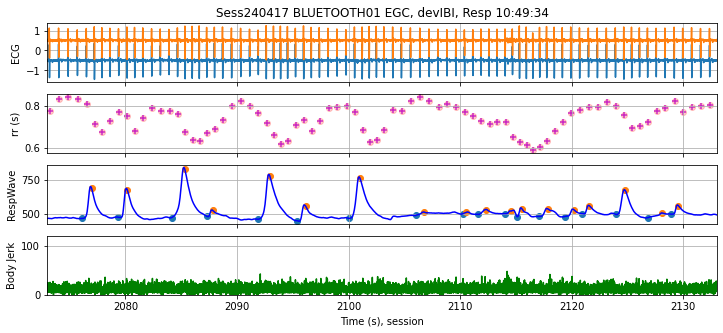

{'Device': 'BLUETOOTH01', 'Start Time': '2024/04/17 10:51:34', 'Recording': 9, 'Initial Beat Count': 86, 'Cleaned Beat Count': 85, 'PC Removed': 1.2, 'Avg HR': 86.56539081727912, 'RMSSD': 40.17051889427487, 'Avg eqHR': 86.5, 'Mode Motion': 'Stationary', 'Mode Posture': 'Upright', 'Breath Count': 10, 'Avg BR': 12.822399047435482, 'Avg IE ratio': 0.22732885656037743, 'Seq Var': 1.770052301174659, 'Avg QoM': 12.150761997569818}


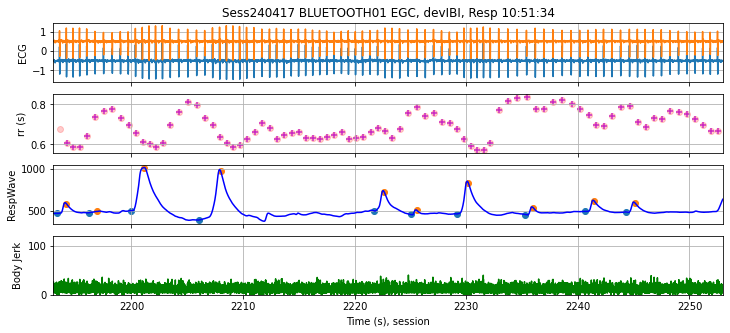

{'Device': 'BLUETOOTH01', 'Start Time': '2024/04/17 10:55:01', 'Recording': 9, 'Initial Beat Count': 82, 'Cleaned Beat Count': 82, 'PC Removed': 0.0, 'Avg HR': 82.44520410215162, 'RMSSD': 36.87047733302936, 'Avg eqHR': 83.66666666666667, 'Mode Motion': 'Stationary', 'Mode Posture': 'Upright', 'Breath Count': 19, 'Avg BR': 25.154402296128925, 'Avg IE ratio': 0.41092036145368627, 'Seq Var': 1.8966933343721004, 'Avg QoM': 12.689588794724534}


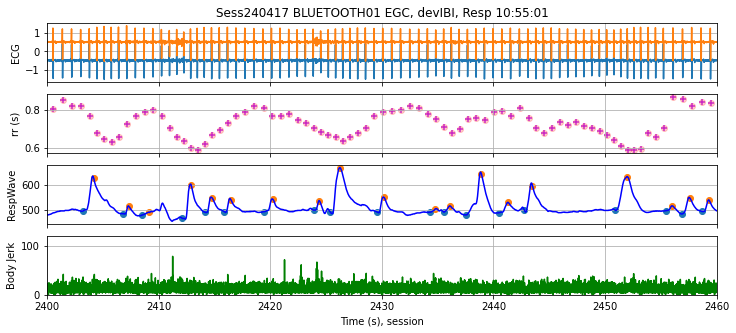

{'Device': 'BLUETOOTH01', 'Start Time': '2024/04/17 10:58:29', 'Recording': 9, 'Initial Beat Count': 81, 'Cleaned Beat Count': 80, 'PC Removed': 1.2, 'Avg HR': 81.25264494286924, 'RMSSD': 43.848460634325576, 'Avg eqHR': 81.75, 'Mode Motion': 'Stationary', 'Mode Posture': 'Upright', 'Breath Count': 14, 'Avg BR': 17.273815892608834, 'Avg IE ratio': 0.3331685082679408, 'Seq Var': 1.9743378260773816, 'Avg QoM': 12.092068790312187}


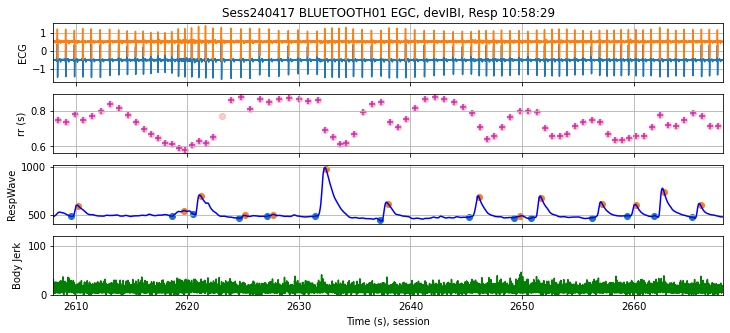

{'Device': 'BLUETOOTH01', 'Start Time': '2024/04/17 11:03:04', 'Recording': 9, 'Initial Beat Count': 92, 'Cleaned Beat Count': 91, 'PC Removed': 1.0999999999999999, 'Avg HR': 92.68847505389851, 'RMSSD': 31.61791118483806, 'Avg eqHR': 93.0, 'Mode Motion': 'Stationary', 'Mode Posture': 'Upright', 'Breath Count': 12, 'Avg BR': 15.365438184375037, 'Avg IE ratio': 0.3142031310151084, 'Seq Var': 1.4384903270185332, 'Avg QoM': 12.881026143254662}


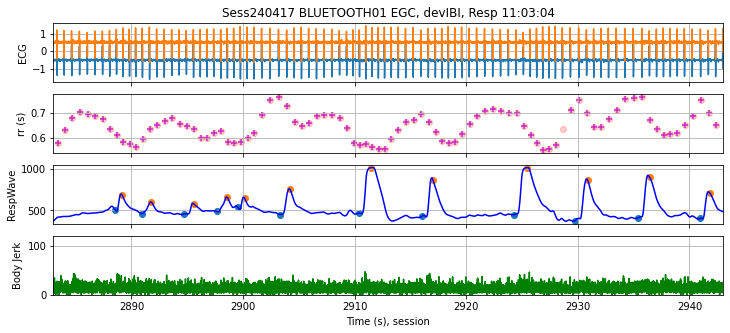

{'Device': 'BLUETOOTH01', 'Start Time': '2024/04/17 11:05:24', 'Recording': 9, 'Initial Beat Count': 92, 'Cleaned Beat Count': 92, 'PC Removed': 0.0, 'Avg HR': 91.79346470441506, 'RMSSD': 30.214253240831535, 'Avg eqHR': 90.75, 'Mode Motion': 'Stationary', 'Mode Posture': 'Upright', 'Breath Count': 8, 'Avg BR': 10.031627716677159, 'Avg IE ratio': 0.1888333357907016, 'Seq Var': 1.7362452787227947, 'Avg QoM': 13.442799246705645}


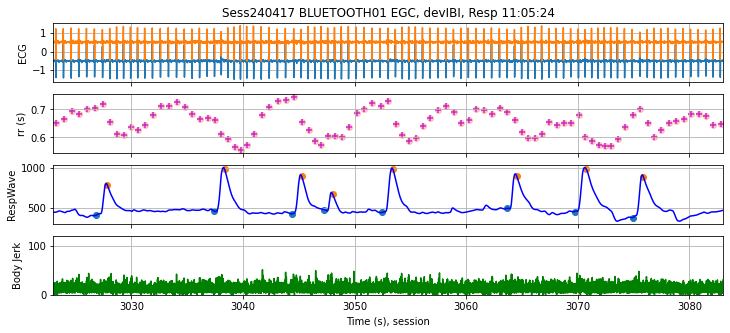

{'Device': 'BLUETOOTH01', 'Start Time': '2024/04/17 11:09:39', 'Recording': 9, 'Initial Beat Count': 90, 'Cleaned Beat Count': 90, 'PC Removed': 0.0, 'Avg HR': 90.03151102886011, 'RMSSD': 28.043906185788444, 'Avg eqHR': 90.5, 'Mode Motion': 'MovingSlowly', 'Mode Posture': 'Upright', 'Breath Count': 17, 'Avg BR': 21.694508474838187, 'Avg IE ratio': 0.6725548085118049, 'Seq Var': 1.9827031556737156, 'Avg QoM': 14.86697464136789}


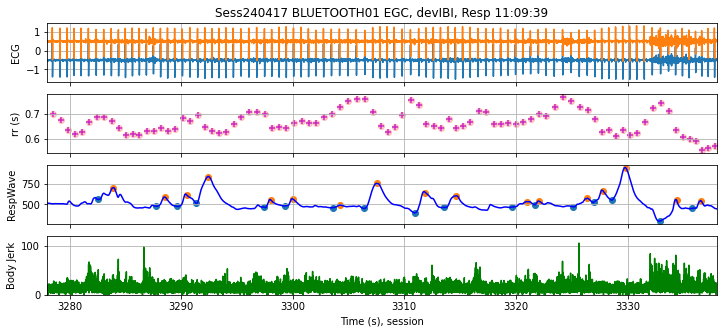

{'Device': 'BLUETOOTH01', 'Start Time': '2024/04/17 11:12:54', 'Recording': 9, 'Initial Beat Count': 84, 'Cleaned Beat Count': 84, 'PC Removed': 0.0, 'Avg HR': 83.93704721458906, 'RMSSD': 30.452807653415206, 'Avg eqHR': 85.0, 'Mode Motion': 'Stationary', 'Mode Posture': 'Upright', 'Breath Count': 18, 'Avg BR': 26.52170384145721, 'Avg IE ratio': 0.5403670296106656, 'Seq Var': 1.748566935490971, 'Avg QoM': 13.208788924625974}


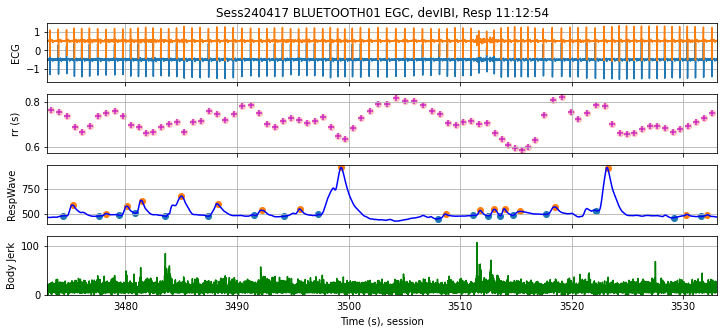

{'Device': 'BLUETOOTH01', 'Start Time': '2024/04/17 11:15:54', 'Recording': 9, 'Initial Beat Count': 79, 'Cleaned Beat Count': 79, 'PC Removed': 0.0, 'Avg HR': 79.32656100948905, 'RMSSD': 28.112639734121604, 'Avg eqHR': 77.5, 'Mode Motion': 'Stationary', 'Mode Posture': 'Upright', 'Breath Count': 19, 'Avg BR': 22.853699125715753, 'Avg IE ratio': 0.5408548223753615, 'Seq Var': 1.704444408876963, 'Avg QoM': 12.65032469736986}


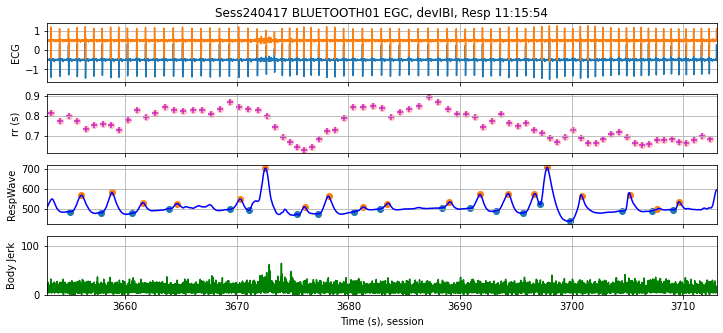

{'Device': 'BLUETOOTH01', 'Start Time': '2024/04/17 11:18:54', 'Recording': 9, 'Initial Beat Count': 79, 'Cleaned Beat Count': 79, 'PC Removed': 0.0, 'Avg HR': 78.86330360708106, 'RMSSD': 22.357812837390757, 'Avg eqHR': 78.0, 'Mode Motion': 'Stationary', 'Mode Posture': 'Upright', 'Breath Count': 26, 'Avg BR': 26.283067773269387, 'Avg IE ratio': 0.6194867150029665, 'Seq Var': 1.1381319942999282, 'Avg QoM': 11.709829397366192}


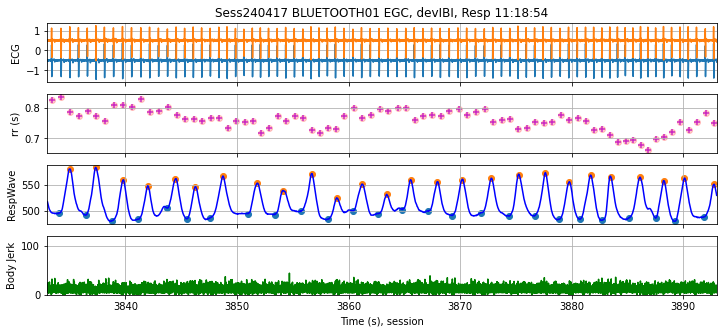

{'Device': 'BLUETOOTH01', 'Start Time': '2024/04/17 11:22:41', 'Recording': 9, 'Initial Beat Count': 88, 'Cleaned Beat Count': 88, 'PC Removed': 0.0, 'Avg HR': 87.46790358651536, 'RMSSD': 29.980261705896147, 'Avg eqHR': 88.5, 'Mode Motion': 'Stationary', 'Mode Posture': 'Upright', 'Breath Count': 17, 'Avg BR': 25.99546464881524, 'Avg IE ratio': 0.5971435941437538, 'Seq Var': 2.0830756276528333, 'Avg QoM': 13.15585303542357}


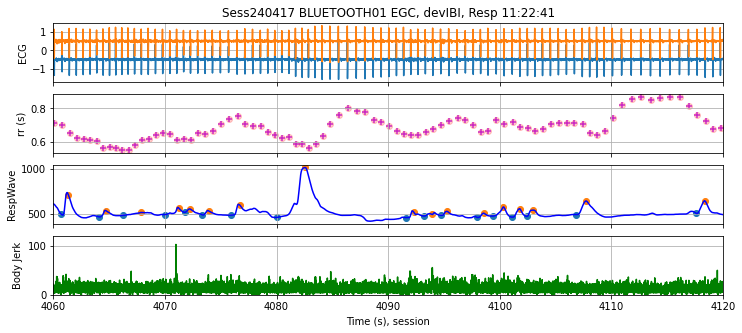

{'Device': 'BLUETOOTH01', 'Start Time': '2024/04/17 11:24:57', 'Recording': 9, 'Initial Beat Count': 74, 'Cleaned Beat Count': 73, 'PC Removed': 1.4000000000000001, 'Avg HR': 74.38858695652173, 'RMSSD': 33.29177774997041, 'Avg eqHR': 75.25, 'Mode Motion': 'Stationary', 'Mode Posture': 'Upright', 'Breath Count': 13, 'Avg BR': 17.570062324534955, 'Avg IE ratio': 0.3907945487011804, 'Seq Var': 1.5405085363124003, 'Avg QoM': 12.059103507340483}


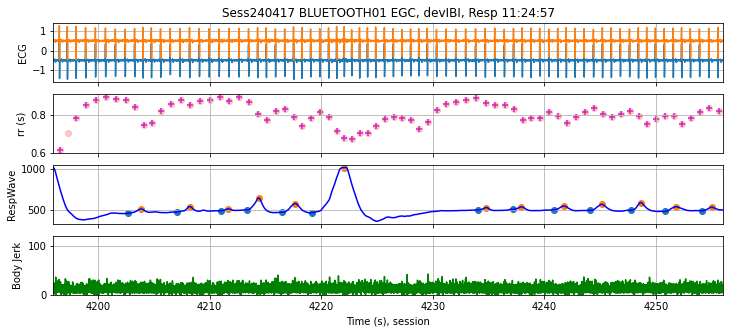

{'Device': 'BLUETOOTH01', 'Start Time': '2024/04/17 11:27:44', 'Recording': 9, 'Initial Beat Count': 77, 'Cleaned Beat Count': 77, 'PC Removed': 0.0, 'Avg HR': 76.75311082684033, 'RMSSD': 35.32275992077987, 'Avg eqHR': 76.75, 'Mode Motion': 'Stationary', 'Mode Posture': 'Upright', 'Breath Count': 18, 'Avg BR': 18.20958823361522, 'Avg IE ratio': 0.4185262447721105, 'Seq Var': 1.1971350790376107, 'Avg QoM': 11.825933661979796}


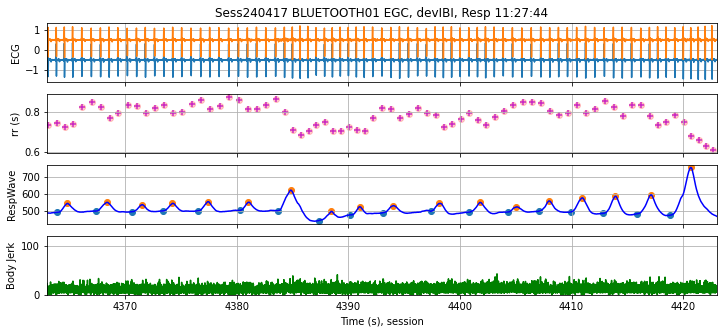

In [113]:
t_int =60
sig_ex = sess_tag + ' '+ dev_tag
session_stats = {}
for t in Excerpt_times: #17
    # needs to be corrected when the files have the right correspondence    
    cht = (t-eqfiles.loc[recindex,'RecStart']).total_seconds()
    chx = cht+t_int
    
    interval_stats = {}
    interval_stats['Device'] = dev_tag
    interval_stats['Start Time'] = t.strftime('%Y/%m/%d %H:%M:%S')
    interval_stats['Recording'] = recindex
    
    fig, (ax) = plt.subplots(4, 1,figsize = [12,5],sharex = True)
    Ex = C.query('c_sTime>@cht and c_sTime<@chx').copy()
    ax[0].plot(Ex['c_sTime'],Ex[' Lead 1']-0.5)
    ax[0].plot(Ex['c_sTime'],Ex[' Lead 2']+0.5)
    ax[0].set_ylabel('ECG')
    ax[0].set_title(sig_ex +' EGC, devIBI, Resp ' + t.strftime('%H:%M:%S') )
    ax[0].set_xlim([cht,chx])
#     ax[0].set_ylim([-1.5,1.5])
    Ex = V.query('c_sTime>@cht and c_sTime<@chx').copy()
    interval_stats['Initial Beat Count'] = len(Ex)

    ax[1].scatter(x =Ex['c_sTime'],y=(Ex[' Interbeat Interval (MS)']/1000),color='r',alpha = 0.2,label='Single Beat')
    Ex = newIBI.query('time>@cht and time<@chx').copy()
    interval_stats['Cleaned Beat Count'] =Ex['IBI'].notna().sum()
    interval_stats['PC Removed'] = 100*np.round((interval_stats['Initial Beat Count'] - interval_stats['Cleaned Beat Count'])/interval_stats['Initial Beat Count'],3)
    ax[1].scatter(x = Ex.index,y = Ex['IBI']/1000,color='m',marker = '+',alpha = 0.8,label='cleared+cleaned')
    interval_stats['Avg HR'] = HR_avg(Ex['IBI'])
    interval_stats['RMSSD'] =rmssd(Ex['IBI'])
    Ex = D.query('c_sTime>@cht and c_sTime<@chx').copy()
    interval_stats['Avg eqHR'] = Ex['HR(BPM)'].mean()
    interval_stats['Mode Motion'] = Ex['MOTION'].mode()[0]
    interval_stats['Mode Posture'] = Ex['BODY POSITION'].mode()[0]
#     ax[1].plot(D['c_sTime'],60/D['HR(BPM)'],alpha=0.7,c='k',label='EQHR')
#     ax[1].legend()
    ax[1].set_ylabel('rr (s)')
#     ax[1].set_ylim([400,1400])

    Ex = R.query('c_sTime>@cht and c_sTime<@chx').copy()
    ax[2].plot(Ex['c_sTime'],Ex[' Breathing'],color = 'b',label='Respiration')
    Ex = Breaths.query('In>@cht and Ex<@chx').copy()
    ax[2].scatter(Ex['In'],Ex['In_C'])
    ax[2].scatter(Ex['Ex'],Ex['Ex_C'])
    ax[2].set_ylabel('RespWave')
    interval_stats['Breath Count'] = len(Ex)
    interval_stats['Avg BR'] =(60/Ex['Period_T']).mean()
    interval_stats['Avg IE ratio'] =(Ex['IE_Ratio']).mean()
    interval_stats['Seq Var'] =np.power(10,np.log10((Ex['Period_T']/Ex['Period_T'].shift(-1))).abs().mean())


    Ex = A.query('c_sTime>@cht and c_sTime<@chx').copy()
    ax[3].plot(Ex['c_sTime'],Ex['QoM'],color = 'g',label='Quantity of Motion')
    ax[3].set(xlabel = 'Time (s), session',ylabel = 'Body Jerk',ylim = [0,120])
    interval_stats['Avg QoM'] =Ex['QoM'].mean()

    ax[3].grid()
    ax[2].grid()
    ax[1].grid()
    ax[0].grid()
    print(interval_stats)
    session_stats[t.strftime('%Y/%m/%d %H:%M:%S')] = interval_stats
    plt.savefig('_'.join(['./plots/'+sess_tag + '/'+sess_tag,t.strftime('%H%M%S'),dev_tag,'excerpt.jpg']))
    plt.show()

Evaluated_Intervals =pd.DataFrame(data=session_stats).transpose()
Evaluated_Intervals.to_csv('_'.join(['./outfiles/'+sess_tag,dev_tag,'fullstats.csv']))

In [108]:
Evs = []

In [114]:

Evs.append(Evaluated_Intervals.copy())

In [115]:
Evs

[                          Device           Start Time Recording  \
 2024/04/17 10:33:19  BLUETOOTH02  2024/04/17 10:33:19         8   
 2024/04/17 10:36:44  BLUETOOTH02  2024/04/17 10:36:44         8   
 2024/04/17 10:39:49  BLUETOOTH02  2024/04/17 10:39:49         8   
 2024/04/17 10:43:28  BLUETOOTH02  2024/04/17 10:43:28         8   
 2024/04/17 10:47:01  BLUETOOTH02  2024/04/17 10:47:01         8   
 2024/04/17 10:49:34  BLUETOOTH02  2024/04/17 10:49:34         8   
 2024/04/17 10:51:34  BLUETOOTH02  2024/04/17 10:51:34         8   
 2024/04/17 10:55:01  BLUETOOTH02  2024/04/17 10:55:01         8   
 2024/04/17 10:58:29  BLUETOOTH02  2024/04/17 10:58:29         8   
 2024/04/17 11:03:04  BLUETOOTH02  2024/04/17 11:03:04         8   
 2024/04/17 11:05:24  BLUETOOTH02  2024/04/17 11:05:24         8   
 2024/04/17 11:09:39  BLUETOOTH02  2024/04/17 11:09:39         8   
 2024/04/17 11:12:54  BLUETOOTH02  2024/04/17 11:12:54         8   
 2024/04/17 11:15:54  BLUETOOTH02  2024/04/17 11

In [116]:
Ex_stats = pd.concat(Evs)

Dan recommended to check manually a very small sample (5 or 10 intervals) at the start of the process. He also wondered if there was a way to track how many artefacts are detected (to be able to report in the article that f.ex "on average, 2% of beats were detected as artefacts"). With regards to respiration, he thought that respiration rate would be best to use as a control - Finn, this is your area of expertise, so we defer to you there.

In [30]:
dev_tag 

'BLUETOOTH01'

In [117]:
# dev_tag = 'BLUETOOTH01'
sub_stats = Ex_stats[['Device','Avg HR','RMSSD','PC Removed','Breath Count','Avg IE ratio','Seq Var','Avg QoM']]
sub_stats.to_csv('./outfiles/'+sess_tag+'_summary.csv')